In [1]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')
from src.visualizer import RAGVisualizer

Available experiments:
         experiment_name                   filename
11      global_bm25_hard      global_bm25_hard.json
2     baseline_bm25_hard    baseline_bm25_hard.json
8            most_fields           most_fields.json
13             high_text             high_text.json
14         high_question         high_question.json
12    global_most_fields    global_most_fields.json
0       global_high_text      global_high_text.json
7   global_high_question  global_high_question.json
6    global_cross_fields   global_cross_fields.json
4            global_bm25           global_bm25.json
10  global_baseline_bm25  global_baseline_bm25.json
9        global_balanced       global_balanced.json
5           cross_fields          cross_fields.json
3          baseline_bm25         baseline_bm25.json
1               balanced              balanced.json


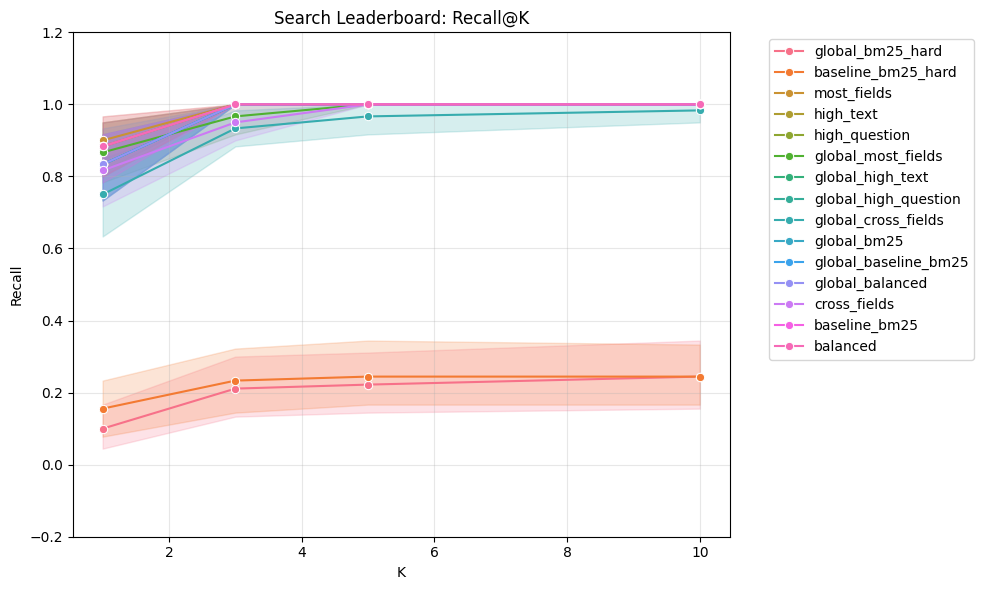

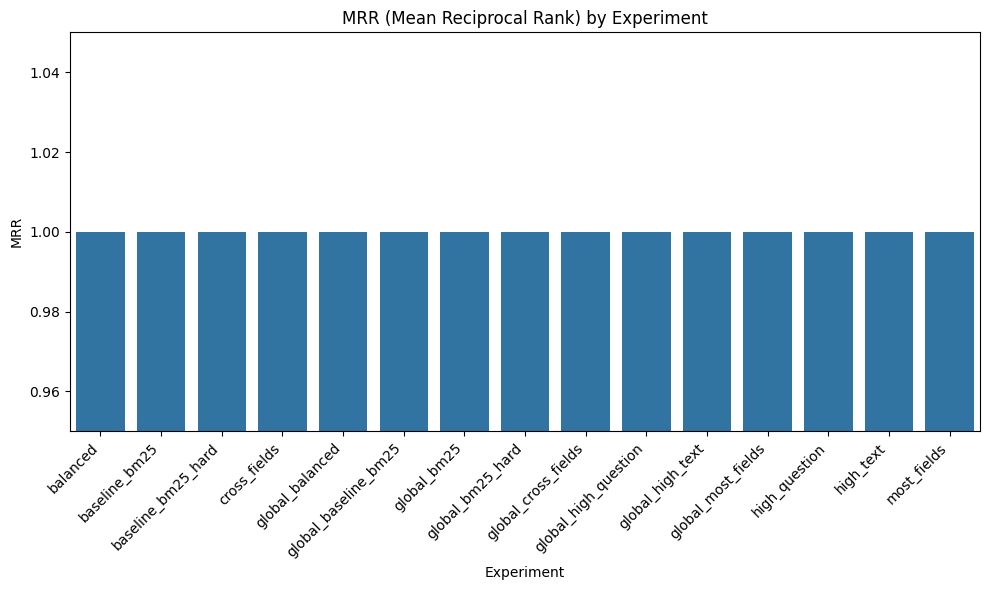

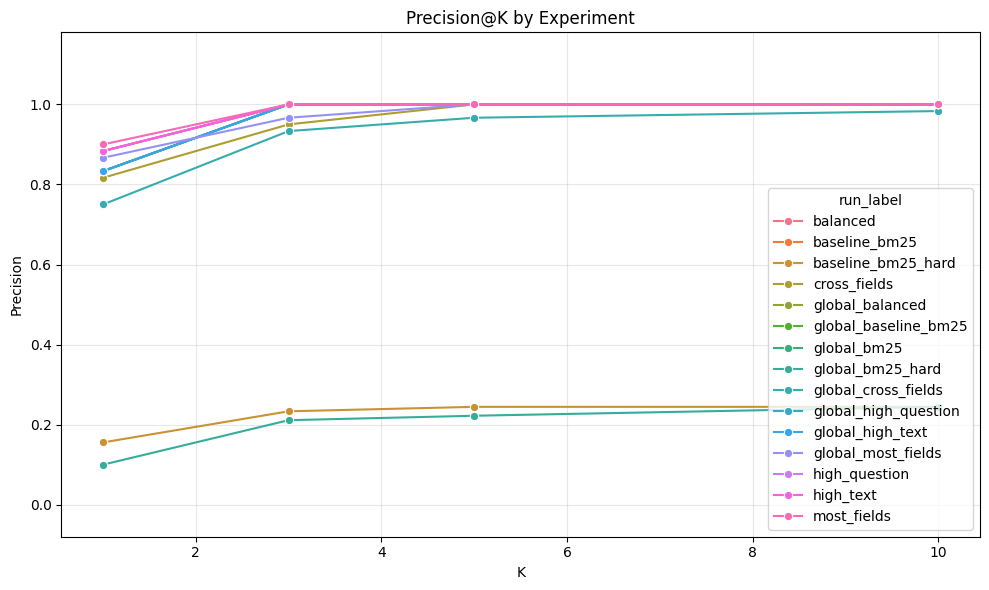

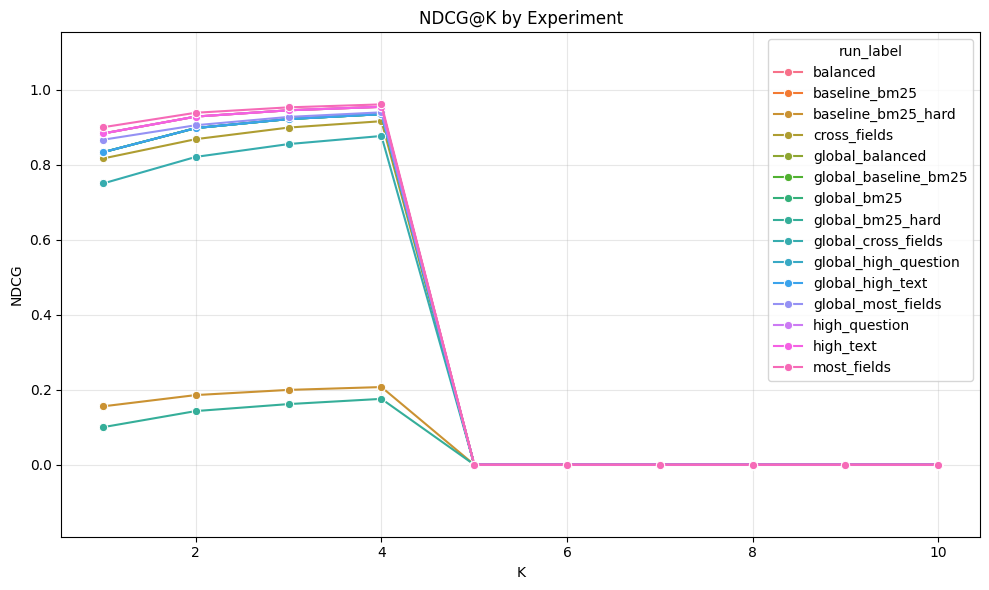

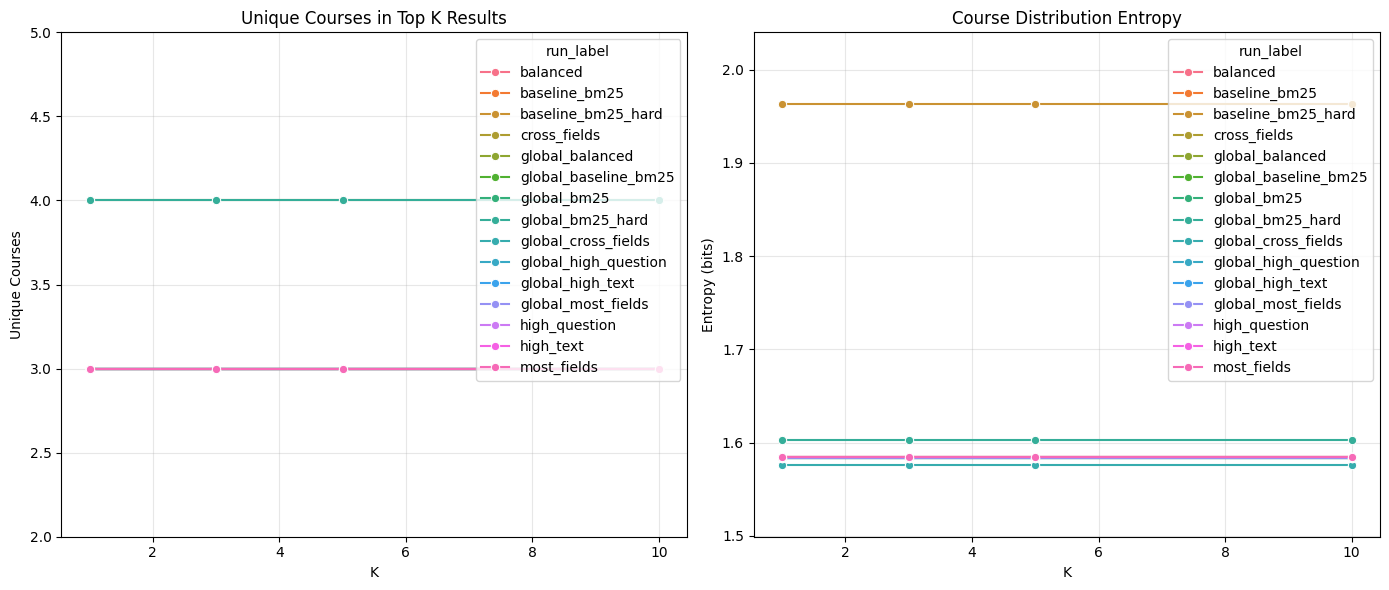

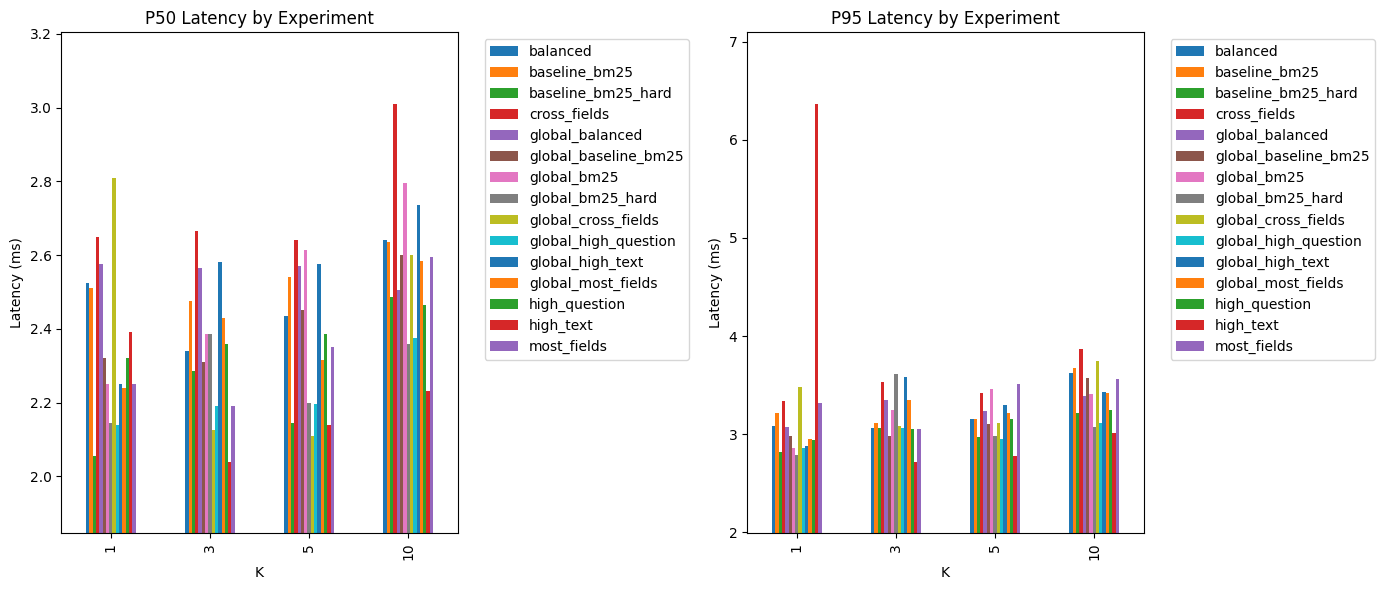

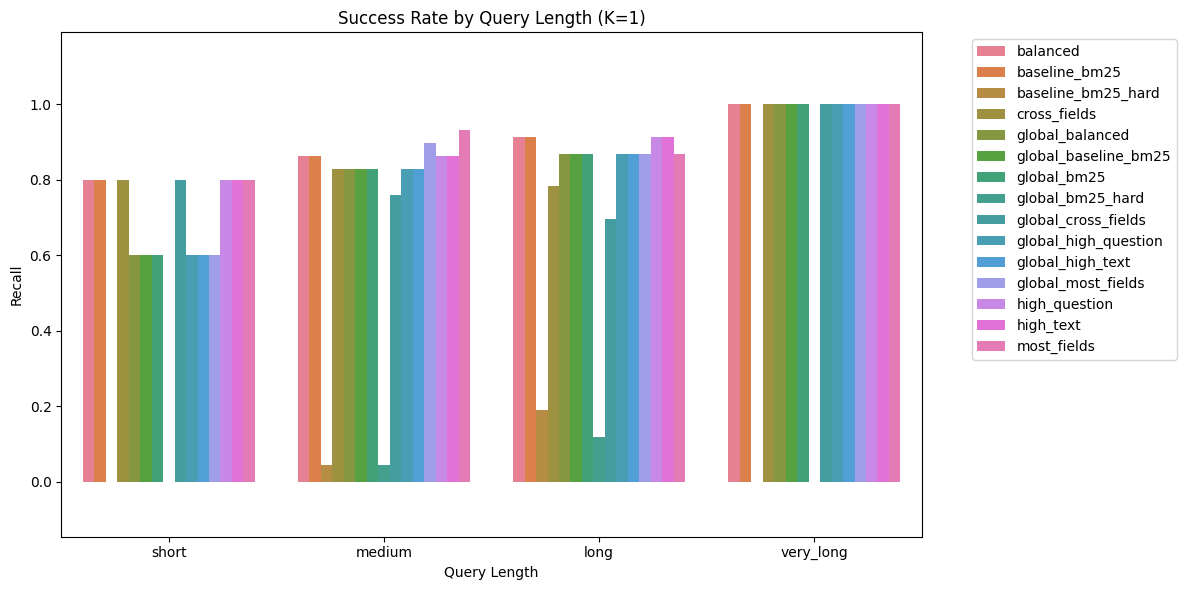

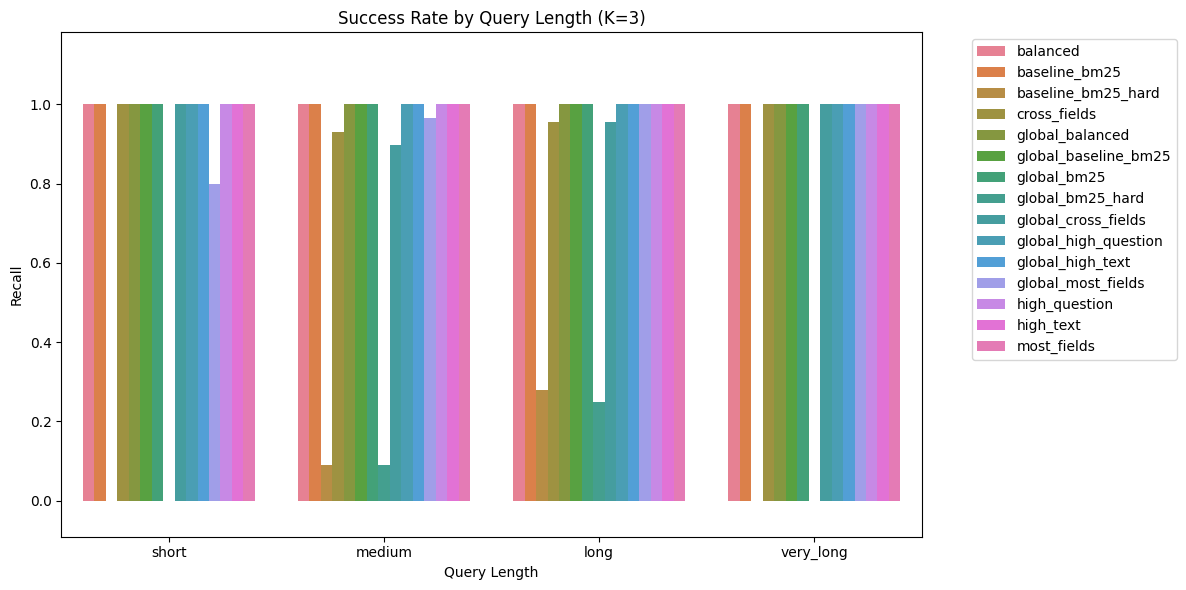

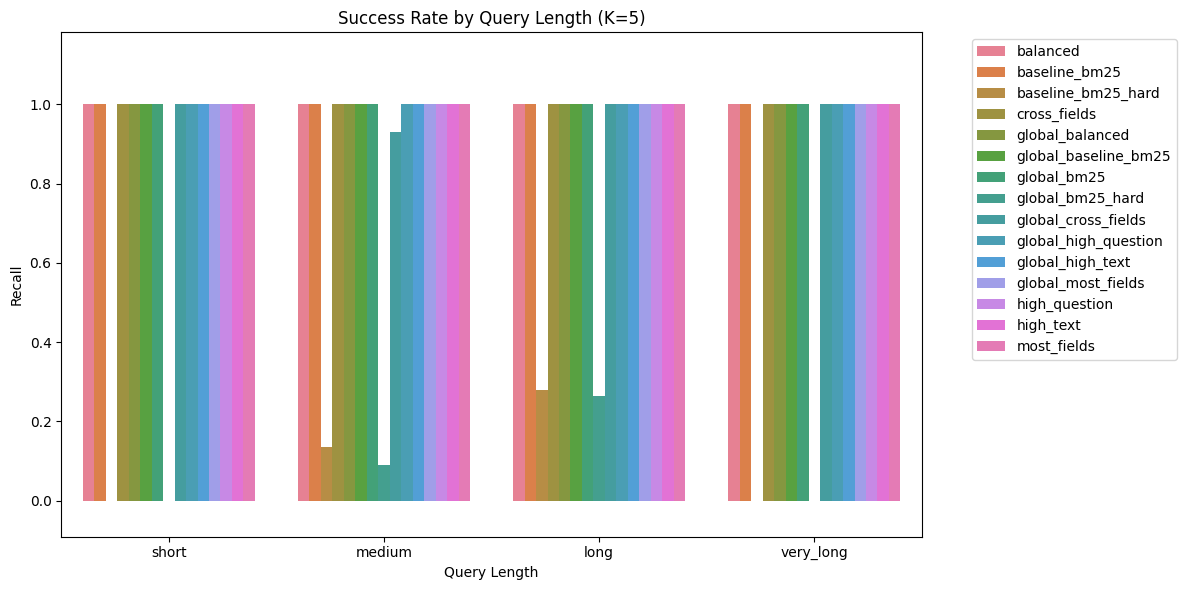

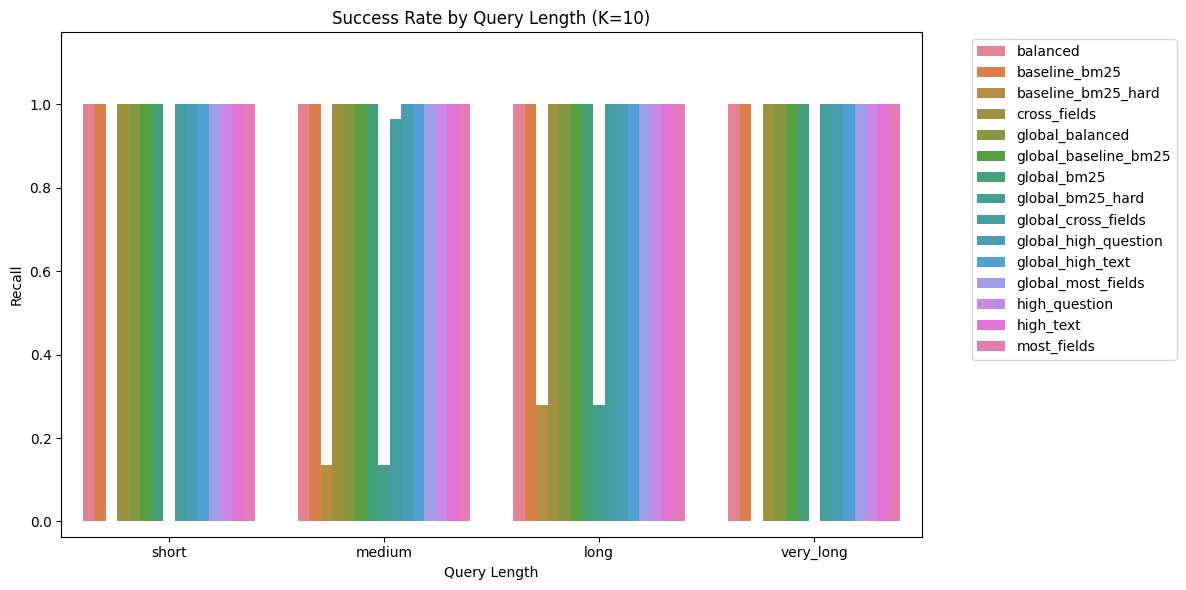

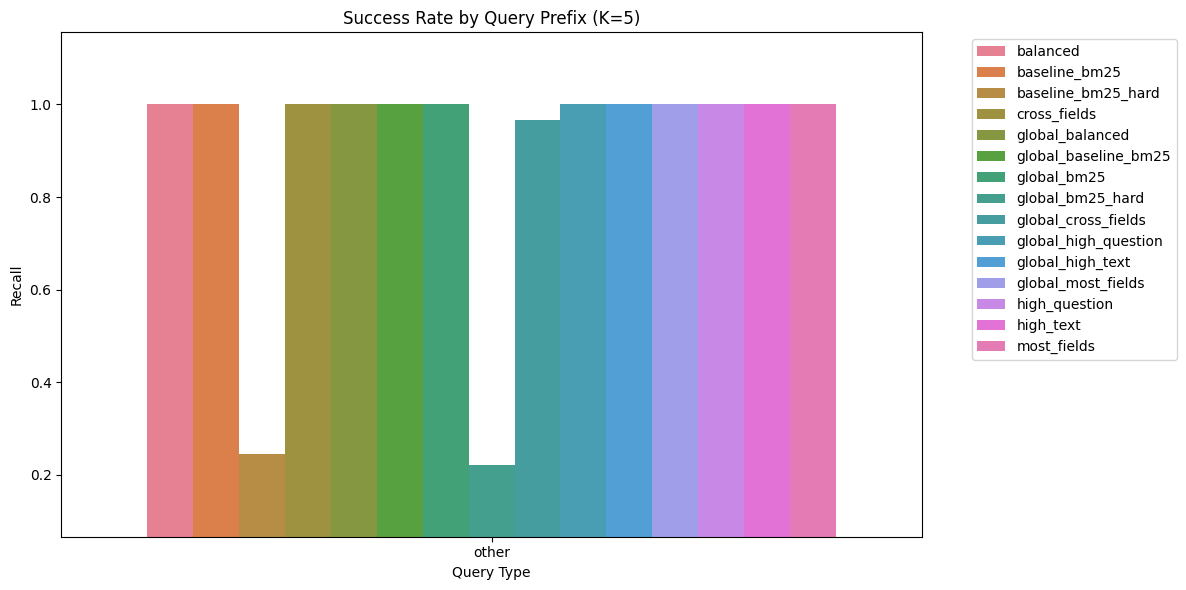


=== Comprehensive Summary (K=5) ===
                      recall@5  mrr  precision@5  hit_rate@5  unique_courses@5  entropy@5  p95_latency_ms
run_label                                                                                                
balanced                1.0000  1.0       1.0000      1.0000                 3     1.5850          3.1525
baseline_bm25           1.0000  1.0       1.0000      1.0000                 3     1.5850          3.1530
baseline_bm25_hard      0.2444  1.0       0.2444      0.2444                 4     1.9626          2.9740
cross_fields            1.0000  1.0       1.0000      1.0000                 3     1.5850          3.4220
global_balanced         1.0000  1.0       1.0000      1.0000                 3     1.5838          3.2335
global_baseline_bm25    1.0000  1.0       1.0000      1.0000                 3     1.5838          3.1030
global_bm25             1.0000  1.0       1.0000      1.0000                 3     1.5838          3.4615
global_bm

In [2]:
from src.visualizer import main
main()


In [3]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
print(registry)

filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

summary = df[df['k'] == 5].groupby('run_label')['success'].mean()
print(summary.sort_values(ascending=False))

                     filename       experiment_name  \
11      global_bm25_hard.json      global_bm25_hard   
2     baseline_bm25_hard.json    baseline_bm25_hard   
8            most_fields.json           most_fields   
13             high_text.json             high_text   
14         high_question.json         high_question   
12    global_most_fields.json    global_most_fields   
0       global_high_text.json      global_high_text   
7   global_high_question.json  global_high_question   
6    global_cross_fields.json   global_cross_fields   
4            global_bm25.json           global_bm25   
10  global_baseline_bm25.json  global_baseline_bm25   
9        global_balanced.json       global_balanced   
5           cross_fields.json          cross_fields   
3          baseline_bm25.json         baseline_bm25   
1               balanced.json              balanced   

                      created_at  \
11 2026-05-04 19:30:17.036792278   
2  2026-05-04 19:30:16.132793188   
8  2026-05-

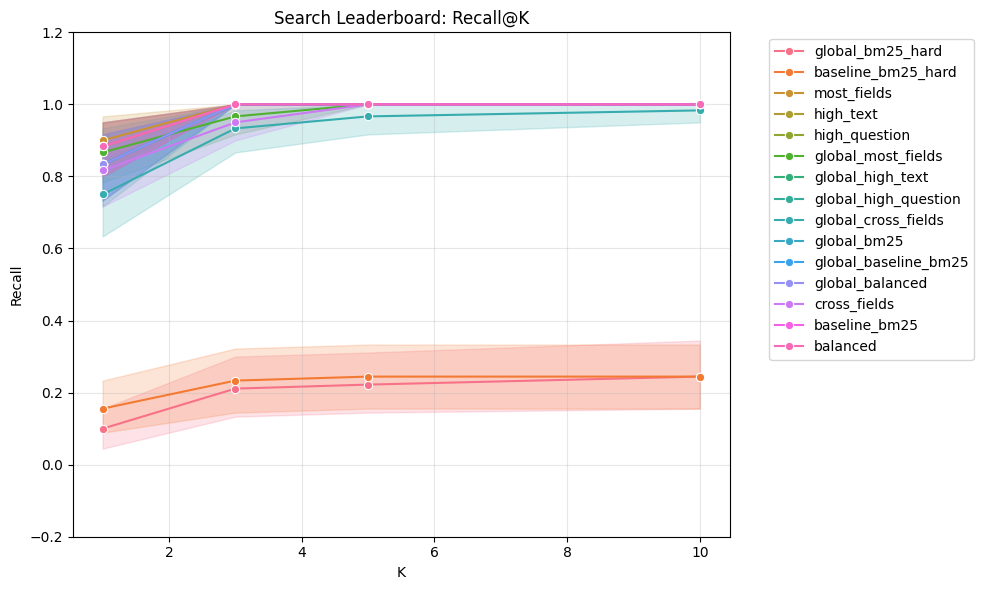

In [4]:
viz.plot_leaderboard(df)


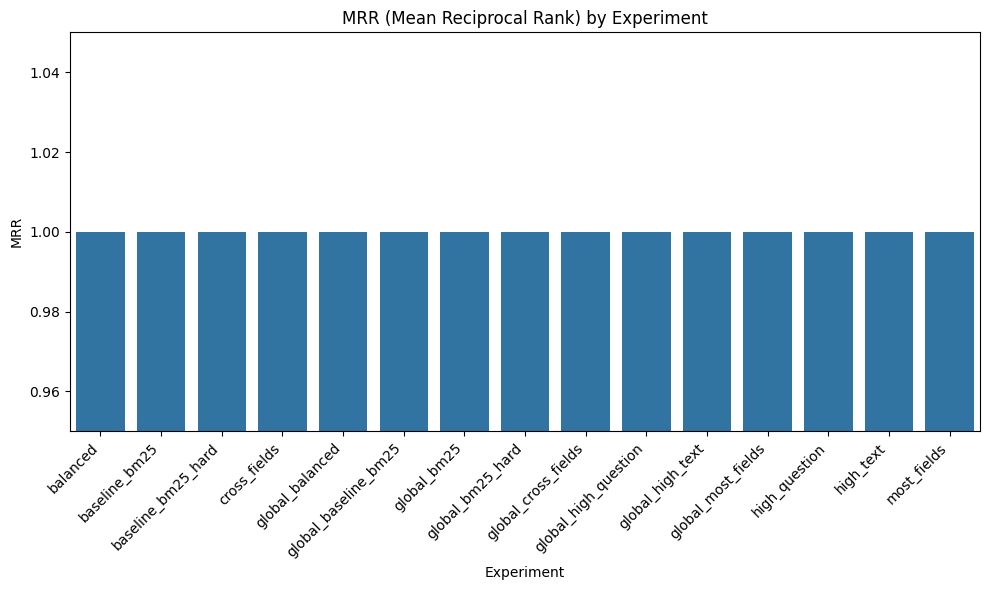

In [5]:
viz.plot_mrr_comparison(viz.compute_mrr(df))


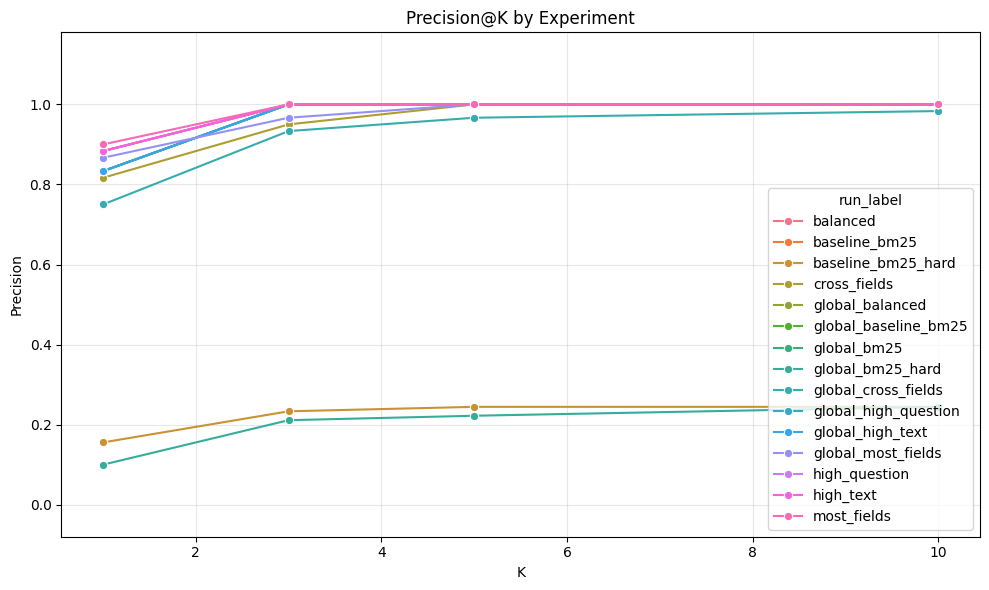

In [6]:
viz.plot_precision_at_k(viz.compute_precision_at_k(df))


In [7]:
def print_all_metrics_to_console(df: pd.DataFrame):
    print("\n" + "="*60)
    print("RETRIEVAL METRICS REPORT")
    print("="*60)
    
    for k in sorted(df['k'].unique()):
        print(f"\n--- K={k} ---")
        
        subset = df[df['k'] == k]
        
        for run in subset['run_label'].unique():
            run_data = subset[subset['run_label'] == run]
            
            recall = run_data['success'].mean()
            precision = run_data['success'].mean()
            hit_rate = run_data['success'].mean()
            avg_latency = run_data['latency_ms'].mean()
            p95_latency = run_data['latency_ms'].quantile(0.95)
            unique_courses = run_data['found_course'].nunique()
            
            print(f"\n  {run}:")
            print(f"    Recall@{k}: {recall:.4f}")
            print(f"    Precision@{k}: {precision:.4f}")
            print(f"    Hit Rate@{k}: {hit_rate:.4f}")
            print(f"    Avg Latency: {avg_latency:.2f} ms")
            print(f"    P95 Latency: {p95_latency:.2f} ms")
            print(f"    Unique Courses in Top {k}: {unique_courses}")
    
    print("\n" + "="*60)
    print("CROSS-COURSE ANALYSIS")
    print("="*60)
    
    df['is_cross_course'] = df['expected_course'] != df['found_course']
    cross_rate = df.groupby(['run_label', 'k'])['is_cross_course'].mean()
    print("\n", cross_rate.to_string())
    
    print("\n" + "="*60)
    print("PER-COURSE BREAKDOWN (K=5)")
    print("="*60)
    
    df_k5 = df[df['k'] == 5]
    course_perf = df_k5.groupby(['run_label', 'expected_course'])['success'].mean()
    print("\n", course_perf.to_string())


# Run it
print_all_metrics_to_console(df)


RETRIEVAL METRICS REPORT

--- K=1 ---

  global_bm25_hard:
    Recall@1: 0.1000
    Precision@1: 0.1000
    Hit Rate@1: 0.1000
    Avg Latency: 2.17 ms
    P95 Latency: 2.79 ms
    Unique Courses in Top 1: 4

  baseline_bm25_hard:
    Recall@1: 0.1556
    Precision@1: 0.1556
    Hit Rate@1: 0.1556
    Avg Latency: 2.12 ms
    P95 Latency: 2.81 ms
    Unique Courses in Top 1: 4

  most_fields:
    Recall@1: 0.9000
    Precision@1: 0.9000
    Hit Rate@1: 0.9000
    Avg Latency: 2.35 ms
    P95 Latency: 3.31 ms
    Unique Courses in Top 1: 3

  high_text:
    Recall@1: 0.8833
    Precision@1: 0.8833
    Hit Rate@1: 0.8833
    Avg Latency: 2.84 ms
    P95 Latency: 6.37 ms
    Unique Courses in Top 1: 3

  high_question:
    Recall@1: 0.8833
    Precision@1: 0.8833
    Hit Rate@1: 0.8833
    Avg Latency: 2.25 ms
    P95 Latency: 2.94 ms
    Unique Courses in Top 1: 3

  global_most_fields:
    Recall@1: 0.8667
    Precision@1: 0.8667
    Hit Rate@1: 0.8667
    Avg Latency: 2.31 ms
    P95 

In [8]:
ndcg_df = viz.compute_ndcg(df)
print(ndcg_df)

       run_label   k      ndcg
0       balanced   1  0.883333
1       balanced   2  0.928466
2       balanced   3  0.945251
3       balanced   4  0.954456
4       balanced   5  0.000000
..           ...  ..       ...
145  most_fields   6  0.000000
146  most_fields   7  0.000000
147  most_fields   8  0.000000
148  most_fields   9  0.000000
149  most_fields  10  0.000000

[150 rows x 3 columns]


In [10]:
from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
print(registry)

filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

# Compare all experiments
summary = df[df['k'] == 5].groupby('run_label')['success'].mean()
print(summary.sort_values(ascending=False))

                     filename       experiment_name  \
11      global_bm25_hard.json      global_bm25_hard   
2     baseline_bm25_hard.json    baseline_bm25_hard   
8            most_fields.json           most_fields   
13             high_text.json             high_text   
14         high_question.json         high_question   
12    global_most_fields.json    global_most_fields   
0       global_high_text.json      global_high_text   
7   global_high_question.json  global_high_question   
6    global_cross_fields.json   global_cross_fields   
4            global_bm25.json           global_bm25   
10  global_baseline_bm25.json  global_baseline_bm25   
9        global_balanced.json       global_balanced   
5           cross_fields.json          cross_fields   
3          baseline_bm25.json         baseline_bm25   
1               balanced.json              balanced   

                      created_at  \
11 2026-05-04 19:30:17.036792278   
2  2026-05-04 19:30:16.132793188   
8  2026-05-

In [11]:
import sys
import os
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')
os.chdir('/home/admin/LLM/LLM/01/web')

from src.search import CourseRAGManager
from src.config_manager import load_config
# /home/admin/LLM/LLM/01/web/analyze_terms.py

import json
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Download stopwords if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

with open("documents.json", "r") as f:
    data = json.load(f)

for course in data:
    print(f"\n=== {course['course']} ===")
    
    all_words = []
    for doc in course['documents']:
        # Clean the question
        question = doc['question']
        if " - " in question:
            question = question.split(" - ", 1)[1].strip()
        
        # Split and filter
        words = question.lower().split()
        words = [w for w in words if w not in stop_words and len(w) > 2]
        all_words.extend(words)
        
        # Also analyze text field (first 200 chars)
        text_words = doc['text'].lower().split()[:50]
        text_words = [w for w in text_words if w not in stop_words and len(w) > 2]
        all_words.extend(text_words)
    
    top_terms = Counter(all_words).most_common(20)
    print(f"Top meaningful terms:")
    for term, count in top_terms:
        print(f"  {term}: {count}")


=== data-engineering-zoomcamp ===
Top meaningful terms:
  error: 158
  docker: 126
  run: 114
  use: 108
  data: 101
  using: 99
  file: 93
  dbt: 70
  install: 68
  error:: 65
  create: 62
  running: 60
  files: 59
  python: 57
  need: 56
  project: 55
  command: 54
  bigquery: 51
  check: 50
  spark: 48

=== machine-learning-zoomcamp ===
Top meaningful terms:
  use: 118
  error: 111
  docker: 104
  using: 92
  get: 73
  install: 67
  run: 62
  model: 61
  need: 48
  command: 47
  image: 47
  import: 44
  running: 43
  data: 42
  one: 41
  solution: 40
  added: 39
  getting: 38
  file: 38
  python: 36

=== mlops-zoomcamp ===
Top meaningful terms:
  error: 49
  mlflow: 44
  using: 43
  added: 38
  aws: 35
  problem: 33
  running: 32
  solution:: 32
  get: 30
  install: 29
  description: 29
  use: 27
  run: 27
  problem:: 26
  command: 25
  solution: 24
  following: 23
  file: 23
  jupyter: 21
  set: 21


[nltk_data] Downloading package stopwords to /home/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
import json
from src.search import CourseRAGManager
from src.config_manager import load_config

# Load a Data Engineering query
with open("documents.json", "r") as f:
    data = json.load(f)

de_course = [c for c in data if c["course"] == "data-engineering-zoomcamp"][0]
sample_doc = de_course["documents"][0]
sample_query = sample_doc["question"].replace("Course - ", "").strip()

print(f"Query: {sample_query}")
print(f"Expected text snippet: {sample_doc['text'][:100]}...")

# Run search
settings = load_config("experiments/configs/baseline_bm25.json")
manager = CourseRAGManager(settings)
manager.connect_elasticsearch()

results = manager.search_faq(sample_query, override_size=5, course_context=None)

print("\n=== Top 5 Results ===")
for i, hit in enumerate(results):
    print(f"{i+1}. Course: {hit['_source']['course']}")
    print(f"   Question: {hit['_source']['question'][:50]}...")
    print(f"   Score: {hit['_score']}")
    print()

2026-05-04 19:30:55,911 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:55,914 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:55,917 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]


Query: When will the course start?
Expected text snippet: The purpose of this document is to capture frequently asked technical questions
The exact day and ho...

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:55,917 [INFO] - Function 'search_faq' executed in 0.0031s

=== Top 5 Results ===
1. Course: data-engineering-zoomcamp
   Question: When will the course start?...
   Score: 10.638114

2. Course: data-engineering-zoomcamp
   Question: Can I follow the course after it finishes?...
   Score: 9.965302

3. Course: machine-learning-zoomcamp
   Question: The course videos are from the previous iteration....
   Score: 9.321284

4. Course: machine-learning-zoomcamp
   Question: I just joined. What should I do next? How can I ac...
   Score: 9.264469

5. Course: machine-learning-zoomcamp
   Question: What If I submitted only two projects and failed t...
   Score: 7.212979



In [13]:
configs_to_test = [
    "baseline_bm25",
    "cross_fields", 
    "high_question",
    "global_cross_fields"
]

for config_name in configs_to_test:
    settings = load_config(f"experiments/configs/{config_name}.json")
    manager = CourseRAGManager(settings)
    manager.connect_elasticsearch()
    
    results = manager.search_faq("When will the course start?", override_size=3, course_context=None)
    
    print(f"\n=== {config_name} ===")
    for hit in results:
        print(f"{hit['_source']['course']}: {hit['_source']['question'][:40]}... (score: {hit['_score']:.2f})")

2026-05-04 19:30:55,930 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 19:30:55,932 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:55,935 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:55,936 [INFO] - Function 'search_faq' executed in 0.0035s


2026-05-04 19:30:55,940 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:55,942 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:55,948 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]



=== baseline_bm25 ===
data-engineering-zoomcamp: When will the course start?... (score: 10.64)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.97)
machine-learning-zoomcamp: The course videos are from the previous ... (score: 9.32)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:55,949 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-04 19:30:55,952 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:55,954 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:55,960 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



=== cross_fields ===
data-engineering-zoomcamp: When will the course start?... (score: 11.49)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.97)
machine-learning-zoomcamp: The course videos are from the previous ... (score: 9.32)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:55,960 [INFO] - Function 'search_faq' executed in 0.0031s


2026-05-04 19:30:55,964 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 19:30:55,967 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:55,972 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



=== high_question ===
data-engineering-zoomcamp: When will the course start?... (score: 10.64)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.97)
machine-learning-zoomcamp: The course videos are from the previous ... (score: 9.32)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:55,972 [INFO] - Function 'search_faq' executed in 0.0034s

=== global_cross_fields ===
data-engineering-zoomcamp: When will the course start?... (score: 11.49)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.97)
machine-learning-zoomcamp: The course videos are from the previous ... (score: 9.32)


In [14]:
import json
with open("experiments/configs/baseline_bm25.json", "r") as f:
    config = json.load(f)
    print("minimum_should_match" in config)
    print(config.get("minimum_should_match"))

True
60%


In [16]:
# Verify document is gone and search properly
from elasticsearch import Elasticsearch

es_client = Elasticsearch("http://localhost:9200")

# Check if document exists
try:
    result = es_client.get(index="course-questions", id="84174a1b33c7f6762ce045729c2ab15e")
    print("Document still exists!")
except Exception as e:
    print("Document deleted successfully")

# Refresh the index to ensure changes are visible
es_client.indices.refresh(index="course-questions")
print("Index refreshed")

# Search with preference to avoid cached results
response = es_client.search(
    index="course-questions",
    query={"match": {"question": "live"}},
    preference="primary_first",
    size=10
)

print("\n=== Documents containing 'live' ===")
for hit in response['hits']['hits']:
    print(f"ID: {hit['_id']} - Question: {hit['_source']['question'][:60]}...")

# Test the original query again
from src.search import CourseRAGManager
from src.config_manager import load_config

settings = load_config("experiments/configs/baseline_bm25.json")
manager = CourseRAGManager(settings)
manager.connect_elasticsearch()

results = manager.search_faq("When will the course start?", override_size=3, course_context=None)

print("\n=== Test query results ===")
for hit in results:
    print(f"{hit['_source']['course']}: {hit['_source']['question'][:50]}...")

2026-05-04 19:30:56,019 [INFO] - GET http://localhost:9200/ [status:200 request:0.004s]
2026-05-04 19:30:56,029 [WARNING] - GET http://localhost:9200/course-questions/_doc/84174a1b33c7f6762ce045729c2ab15e [status:404 request:0.009s]
2026-05-04 19:30:56,034 [INFO] - POST http://localhost:9200/course-questions/_refresh [status:200 request:0.005s]
2026-05-04 19:30:56,038 [INFO] - POST http://localhost:9200/course-questions/_search?preference=primary_first [status:200 request:0.002s]
2026-05-04 19:30:56,043 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:56,045 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:56,048 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]


Document deleted successfully
Index refreshed

=== Documents containing 'live' ===
ID: 855bc172ac512fcbd69143c794eba26b - Question: Besides the “Office Hour” which are the live zoom calls?...

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:56,049 [INFO] - Function 'search_faq' executed in 0.0031s

=== Test query results ===
data-engineering-zoomcamp: When will the course start?...
data-engineering-zoomcamp: Can I follow the course after it finishes?...
machine-learning-zoomcamp: The course videos are from the previous iteration....


In [18]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

# Check Data Engineering recall specifically
de_recall = df[(df['k'] == 5) & (df['expected_course'] == 'data-engineering-zoomcamp')].groupby('run_label')['success'].mean()
print("Data Engineering Recall@5 after cleanup:")
print(de_recall.sort_values(ascending=False))

Data Engineering Recall@5 after cleanup:
run_label
balanced                1.000000
baseline_bm25           1.000000
cross_fields            1.000000
global_baseline_bm25    1.000000
global_balanced         1.000000
global_bm25             1.000000
global_high_text        1.000000
high_text               1.000000
global_high_question    1.000000
high_question           1.000000
global_most_fields      1.000000
most_fields             1.000000
global_cross_fields     0.950000
baseline_bm25_hard      0.233333
global_bm25_hard        0.166667
Name: success, dtype: float64


In [19]:
from elasticsearch import Elasticsearch
import json

es_client = Elasticsearch("http://localhost:9200")

# Load a specific Data Engineering query from documents.json
with open("documents.json", "r") as f:
    data = json.load(f)

# Find a Data Engineering document
de_course = None
for course in data:
    if course["course"] == "data-engineering-zoomcamp":
        de_course = course
        break

if de_course:
    # Get first document and clean the question
    sample_doc = de_course["documents"][0]
    sample_query = sample_doc["question"]
    if " - " in sample_query:
        sample_query = sample_query.split(" - ", 1)[1].strip()
    
    expected_id = None
    # Find the expected ID for this document
    from src.core import generate_document_id
    test_doc = {
        "text": sample_doc["text"],
        "question": sample_query,
        "course": de_course["course"]
    }
    expected_id = generate_document_id(test_doc)
    
    print(f"Query: {sample_query}")
    print(f"Expected ID: {expected_id}")
    print(f"Expected Course: {de_course['course']}")
    print()
    
    # Search
    response = es_client.search(
        index="course-questions",
        query={"match": {"question": sample_query}},
        size=5
    )
    
    print("=== Search Results ===")
    for i, hit in enumerate(response['hits']['hits']):
        print(f"{i+1}. ID: {hit['_id']}")
        print(f"   Course: {hit['_source']['course']}")
        print(f"   Question: {hit['_source']['question'][:60]}...")
        print(f"   Match: {'✅ EXPECTED' if hit['_id'] == expected_id else '❌'}")
        print()
    
    # Check if expected document exists in index
    try:
        es_client.get(index="course-questions", id=expected_id)
        print(f"Expected document {expected_id} EXISTS in Elasticsearch")
    except Exception as e:
        print(f"Expected document {expected_id} NOT FOUND in Elasticsearch: {e}")

2026-05-04 19:30:56,151 [WARNING] - python-dotenv could not parse statement starting at line 6
2026-05-04 19:30:58,112 [WARNING] - python-dotenv could not parse statement starting at line 6
2026-05-04 19:30:58,702 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 19:30:58,705 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]
2026-05-04 19:30:58,710 [INFO] - GET http://localhost:9200/course-questions/_doc/99e9b6dab2ba7735f46b9a336f9aa501 [status:200 request:0.003s]


Query: When will the course start?
Expected ID: 99e9b6dab2ba7735f46b9a336f9aa501
Expected Course: data-engineering-zoomcamp

=== Search Results ===
1. ID: 99e9b6dab2ba7735f46b9a336f9aa501
   Course: data-engineering-zoomcamp
   Question: When will the course start?...
   Match: ✅ EXPECTED

2. ID: a60302f9270595d1b867f11cd02bc240
   Course: mlops-zoomcamp
   Question: Will there be a 2024 Cohort? When will the 2024 cohort start...
   Match: ❌

3. ID: bb3f633915b881e8d6e310d2aca2b249
   Course: machine-learning-zoomcamp
   Question: When does the next iteration start?...
   Match: ❌

4. ID: 2377feef9b2e4d76a9549965a756eb71
   Course: data-engineering-zoomcamp
   Question: Can I still join the course after the start date?...
   Match: ❌

5. ID: 1bc41f5051cf8798175fa8dfa1f57617
   Course: machine-learning-zoomcamp
   Question: The course videos are from the previous iteration. Will you ...
   Match: ❌

Expected document 99e9b6dab2ba7735f46b9a336f9aa501 EXISTS in Elasticsearch


In [20]:
from src.run_stats import get_eval_set
from src.core import generate_document_id
import json

# Load documents to see what IDs are being generated
with open("documents.json", "r") as f:
    raw_data = json.load(f)

# Generate IDs for Data Engineering documents
print("=== IDs from generate_document_id() ===")
for course in raw_data:
    if course["course"] == "data-engineering-zoomcamp":
        for i, doc in enumerate(course["documents"][:3]):
            test_doc = {
                "text": doc["text"],
                "question": doc["question"],
                "course": course["course"]
            }
            doc_id = generate_document_id(test_doc)
            print(f"{i+1}. Question: {doc['question'][:50]}...")
            print(f"   Generated ID: {doc_id}")
            print()

# Get eval set and check its IDs
eval_set = get_eval_set("documents.json", n_per_course=10)
print("=== Eval set sample (Data Engineering) ===")
de_items = [item for item in eval_set if item["course"] == "data-engineering-zoomcamp"]
for item in de_items[:3]:
    print(f"Query: {item['query'][:50]}...")
    print(f"Expected ID from eval set: {item['expected_id']}")
    print()

=== IDs from generate_document_id() ===
1. Question: Course - When will the course start?...
   Generated ID: 071ea213dbd1d18cc34556acf1159a55

2. Question: Course - What are the prerequisites for this cours...
   Generated ID: 7a9144107b3ee2759085093a503d13a7

3. Question: Course - Can I still join the course after the sta...
   Generated ID: 64ffc7d1ca671d36b8029dbaa46fb90f

=== Eval set sample (Data Engineering) ===
Query: When will the course start?...
Expected ID from eval set: 99e9b6dab2ba7735f46b9a336f9aa501

Query: What are the prerequisites for this course?...
Expected ID from eval set: a0ec1082f599e540ff13544a97505e8a

Query: Can I still join the course after the start date?...
Expected ID from eval set: 2377feef9b2e4d76a9549965a756eb71



In [21]:
from elasticsearch import Elasticsearch

es_client = Elasticsearch("http://localhost:9200")

# Search for Data Engineering documents
response = es_client.search(
    index="course-questions",
    query={"term": {"course": "data-engineering-zoomcamp"}},
    size=5
)

print("=== Actual IDs in Elasticsearch (Data Engineering) ===")
for hit in response['hits']['hits']:
    print(f"ID: {hit['_id']}")
    print(f"Question: {hit['_source']['question'][:50]}...")
    print()

2026-05-04 19:30:58,741 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 19:30:58,746 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.004s]


=== Actual IDs in Elasticsearch (Data Engineering) ===
ID: 99e9b6dab2ba7735f46b9a336f9aa501
Question: When will the course start?...

ID: a0ec1082f599e540ff13544a97505e8a
Question: What are the prerequisites for this course?...

ID: 2377feef9b2e4d76a9549965a756eb71
Question: Can I still join the course after the start date?...

ID: 34a4df0dcbb490bdb6d22d297a371a2a
Question: I have registered for the Data Engineering Bootcam...

ID: 393ba6526e56a4e531413adaf596ff0f
Question: What can I do before the course starts?...



In [22]:
from src.run_stats import get_eval_set
from src.core import generate_document_id
import json
import os

web_root = "/home/admin/LLM/LLM/01/web"
documents_path = os.path.join(web_root, "documents.json")

with open(documents_path, "r") as f:
    raw_data = json.load(f)

print("=== IDs from generate_document_id() ===")
for course in raw_data:
    if course["course"] == "data-engineering-zoomcamp":
        for i, doc in enumerate(course["documents"][:3]):
            clean_question = doc["question"]
            if " - " in clean_question:
                clean_question = clean_question.split(" - ", 1)[1].strip()
            
            test_doc = {
                "text": doc["text"],
                "question": clean_question,
                "course": course["course"]
            }
            doc_id = generate_document_id(test_doc)
            print(f"{i+1}. Clean Question: {clean_question[:50]}...")
            print(f"   Generated ID: {doc_id}")
            print()

eval_set = get_eval_set("documents.json", n_per_course=10)
print("=== Eval set sample (Data Engineering) ===")
de_items = [item for item in eval_set if item["course"] == "data-engineering-zoomcamp"]
for item in de_items[:3]:
    print(f"Query: {item['query'][:50]}...")
    print(f"Expected ID from eval set: {item['expected_id']}")
    print()

=== IDs from generate_document_id() ===
1. Clean Question: When will the course start?...
   Generated ID: 99e9b6dab2ba7735f46b9a336f9aa501

2. Clean Question: What are the prerequisites for this course?...
   Generated ID: a0ec1082f599e540ff13544a97505e8a

3. Clean Question: Can I still join the course after the start date?...
   Generated ID: 2377feef9b2e4d76a9549965a756eb71

=== Eval set sample (Data Engineering) ===
Query: When will the course start?...
Expected ID from eval set: 99e9b6dab2ba7735f46b9a336f9aa501

Query: What are the prerequisites for this course?...
Expected ID from eval set: a0ec1082f599e540ff13544a97505e8a

Query: Can I still join the course after the start date?...
Expected ID from eval set: 2377feef9b2e4d76a9549965a756eb71



In [23]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

# Check Data Engineering recall specifically
de_recall = df[(df['k'] == 5) & (df['expected_course'] == 'data-engineering-zoomcamp')].groupby('run_label')['success'].mean()
print("Data Engineering Recall@5 after ID fix:")
print(de_recall.sort_values(ascending=False))

# Overall recall
print("\nOverall Recall@5:")
print(df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False))

Data Engineering Recall@5 after ID fix:
run_label
balanced                1.000000
baseline_bm25           1.000000
cross_fields            1.000000
global_baseline_bm25    1.000000
global_balanced         1.000000
global_bm25             1.000000
global_high_text        1.000000
high_text               1.000000
global_high_question    1.000000
high_question           1.000000
global_most_fields      1.000000
most_fields             1.000000
global_cross_fields     0.950000
baseline_bm25_hard      0.233333
global_bm25_hard        0.166667
Name: success, dtype: float64

Overall Recall@5:
run_label
balanced                1.000000
baseline_bm25           1.000000
cross_fields            1.000000
global_baseline_bm25    1.000000
global_balanced         1.000000
global_bm25             1.000000
global_high_text        1.000000
high_text               1.000000
global_high_question    1.000000
high_question           1.000000
global_most_fields      1.000000
most_fields             1.000000


In [25]:
from src.stats import StatsCollector
from src.config_manager import load_config

settings = load_config("experiments/configs/baseline_bm25.json")
collector = StatsCollector("experiments/configs/baseline_bm25.json")
collector.manager.connect_elasticsearch()

# Create a test item
test_item = {
    "query": "When will the course start?",
    "course": "data-engineering-zoomcamp",
    "expected_id": "99e9b6dab2ba7735f46b9a336f9aa501"
}

# Run search manually as stats.py would
hits = collector.manager.search_faq(
    query=test_item["query"],
    override_size=5,
    course_context=None  # Use None for global, or test_item["course"] for filtered
)

print(f"Expected ID: {test_item['expected_id']}")
print(f"Found IDs: {[h['_id'] for h in hits]}")
print(f"Success: {test_item['expected_id'] in [h['_id'] for h in hits]}")

2026-05-04 19:30:58,868 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:58,870 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:58,874 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 19:30:58,875 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 19:30:58,879 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 19:30:58,880 [INFO] - Function 'search_faq' executed in 0.0040s
Expected ID: 99e9b6dab2ba7735f46b9a336f9aa501
Found IDs: ['99e9b6dab2ba7735f46b9a336f9aa501', 'd1eaabb6ca61fe0fbb8bd90baebadf1d', '1bc41f5051cf8798175fa8dfa1f57617', '3b8d2adb30a3d924eac541ba1659f198', 'b481e48d603589ca5f6d659e15a0e031']
Success: True


In [28]:
import os
import json

results_dir = "experiments/results"
for fname in os.listdir(results_dir):
    if fname.endswith(".json"):
        filepath = os.path.join(results_dir, fname)
        mtime = os.path.getmtime(filepath)
        from datetime import datetime
        print(f"{fname}: {datetime.fromtimestamp(mtime)}")
        
        # Check first result for Data Engineering
        with open(filepath, 'r') as f:
            data = json.load(f)
            first_de = None
            for result in data['results']:
                if result['expected_course'] == 'data-engineering-zoomcamp':
                    first_de = result
                    break
            if first_de:
                print(f"  Sample: {first_de['query'][:40]}... success={first_de['success']}")

global_high_text.json: 2026-05-04 19:30:07.904801
  Sample: When will the course start?... success=True
balanced.json: 2026-05-04 19:30:02.616806
  Sample: When will the course start?... success=True
baseline_bm25_hard.json: 2026-05-04 19:30:16.132793
  Sample: What's the scheduled start date for the ... success=False
baseline_bm25.json: 2026-05-04 19:30:03.284806
  Sample: When will the course start?... success=True
global_bm25.json: 2026-05-04 19:30:05.988803
  Sample: When will the course start?... success=True
cross_fields.json: 2026-05-04 19:30:04.000805
  Sample: When will the course start?... success=True
global_cross_fields.json: 2026-05-04 19:30:06.636802
  Sample: When will the course start?... success=True
global_high_question.json: 2026-05-04 19:30:07.224802
  Sample: When will the course start?... success=True
most_fields.json: 2026-05-04 19:30:10.408799
  Sample: When will the course start?... success=True
global_balanced.json: 2026-05-04 19:30:04.684804
  Sample: When wi

In [29]:
# Run this in your notebook or as a script
import pandas as pd

# Create results from the A/B test output
data = {
    'query': [
        'When will the course start?',
        'What are the prerequisites for this course?',
        'Can I still join the course after the start date?',
        'How do I sign up?',
        'What if I miss a session?',
        'How much theory will you cover?',
        'Format for questions: [Problem title]',
        'What is the expected duration of this course or that for each module?',
        'What’s the difference between the 2023 and 2022 course?'
    ],
    'expected_course': [
        'DE', 'DE', 'DE', 'ML', 'ML', 'ML', 'MLOps', 'MLOps', 'MLOps'
    ],
    'config_a_course': [
        'DE', 'DE', 'DE', 'ML', 'ML', 'ML', 'MLOps', 'MLOps', 'MLOps'
    ],
    'config_b_course': [
        'DE', 'DE', 'DE', 'ML', 'ML', 'ML', 'MLOps', 'MLOps', 'ML'  # Wrong course on #9
    ],
    'config_a_score': [10.64, 13.33, 19.52, 10.99, 14.05, 16.91, 13.89, 20.11, 18.66],
    'config_b_score': [11.49, 14.15, 19.52, 10.99, 13.39, 20.04, 13.95, 18.17, 20.81]
}

df_ab = pd.DataFrame(data)

# Determine winner based on score (with tie handling)
def determine_winner(row):
    if row['config_a_course'] != row['expected_course'] and row['config_b_course'] == row['expected_course']:
        return 'B'  # B returned correct course, A didn't
    elif row['config_b_course'] != row['expected_course'] and row['config_a_course'] == row['expected_course']:
        return 'A'  # A returned correct course, B didn't
    elif row['config_a_score'] > row['config_b_score']:
        return 'A'
    elif row['config_b_score'] > row['config_a_score']:
        return 'B'
    else:
        return 'TIE'

df_ab['winner'] = df_ab.apply(determine_winner, axis=1)

print("=== A/B TEST RESULTS ===")
print(f"Total queries: {len(df_ab)}")
print(f"\nWinner counts:")
print(df_ab['winner'].value_counts())
print(f"\nWinner by config:")
print(f"Config A (baseline_bm25): {(df_ab['winner'] == 'A').sum()} wins")
print(f"Config B (global_cross_fields): {(df_ab['winner'] == 'B').sum()} wins")
print(f"Ties: {(df_ab['winner'] == 'TIE').sum()}")

print("\n=== DETAILS ===")
for _, row in df_ab.iterrows():
    print(f"\n{row['query'][:50]}...")
    print(f"  Expected: {row['expected_course']}")
    print(f"  A: {row['config_a_course']} (score: {row['config_a_score']})")
    print(f"  B: {row['config_b_course']} (score: {row['config_b_score']})")
    print(f"  Winner: {row['winner']}")

=== A/B TEST RESULTS ===
Total queries: 9

Winner counts:
winner
B      4
A      3
TIE    2
Name: count, dtype: int64

Winner by config:
Config A (baseline_bm25): 3 wins
Config B (global_cross_fields): 4 wins
Ties: 2

=== DETAILS ===

When will the course start?...
  Expected: DE
  A: DE (score: 10.64)
  B: DE (score: 11.49)
  Winner: B

What are the prerequisites for this course?...
  Expected: DE
  A: DE (score: 13.33)
  B: DE (score: 14.15)
  Winner: B

Can I still join the course after the start date?...
  Expected: DE
  A: DE (score: 19.52)
  B: DE (score: 19.52)
  Winner: TIE

How do I sign up?...
  Expected: ML
  A: ML (score: 10.99)
  B: ML (score: 10.99)
  Winner: TIE

What if I miss a session?...
  Expected: ML
  A: ML (score: 14.05)
  B: ML (score: 13.39)
  Winner: A

How much theory will you cover?...
  Expected: ML
  A: ML (score: 16.91)
  B: ML (score: 20.04)
  Winner: B

Format for questions: [Problem title]...
  Expected: MLOps
  A: MLOps (score: 13.89)
  B: MLOps (scor